✅ Crédit accepté


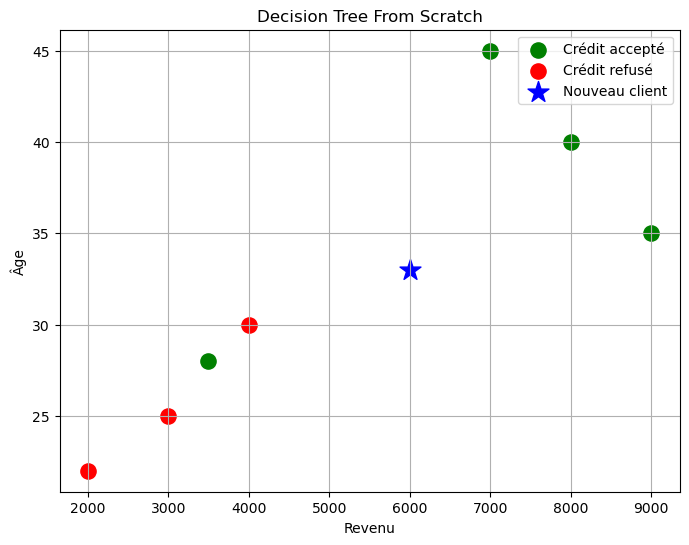

In [2]:
# ============================================================
#   Arbre de Décision (Decision Tree) FROM SCRATCH EN PYTHON
# ============================================================
# Situation :
# Une banque veut décider si elle accepte un crédit ou non.
#
# Variables :
# X1 = revenu mensuel
# X2 = dette (0 = pas de dette, 1 = dette)
# X3 = âge
#
# Sortie :
# y = 1 → crédit accepté
# y = 0 → crédit refusé
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. CALCUL DE L’ENTROPIE
# ============================================================
# L'entropie mesure le niveau de désordre des données.
#
# Si toutes les données appartiennent à la même classe :
# → entropie faible
#
# Si les classes sont mélangées :
# → entropie élevée
#
# Formule :
# Entropy = - Σ(p * log2(p))
# ============================================================

def entropy(y):

    # récupération des classes et leurs occurrences
    classes, counts = np.unique(y, return_counts=True)

    # calcul des probabilités
    probabilities = counts / counts.sum()

    # initialisation
    ent = 0

    # application de la formule
    for p in probabilities:
        ent -= p * np.log2(p)

    return ent


# ============================================================
# 2. CALCUL DU GAIN D’INFORMATION
# ============================================================
# Le gain d'information permet de choisir
# le meilleur split.
#
# Formule :
# Gain = Entropy(parent) - Entropy(enfants)
#
# Plus le gain est grand :
# → meilleure séparation
# ============================================================

def information_gain(X_column, y, threshold):

    # séparation des données
    left_indices = X_column <= threshold
    right_indices = X_column > threshold

    # éviter les groupes vides
    if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
        return 0

    # entropie avant division
    parent_entropy = entropy(y)

    # taille totale
    n = len(y)

    # tailles des groupes
    n_left = len(y[left_indices])
    n_right = len(y[right_indices])

    # entropie des sous-groupes
    e_left = entropy(y[left_indices])
    e_right = entropy(y[right_indices])

    # moyenne pondérée
    child_entropy = (
        (n_left / n) * e_left +
        (n_right / n) * e_right
    )

    # calcul du gain
    ig = parent_entropy - child_entropy

    return ig


# ============================================================
# 3. CLASSE NODE
# ============================================================
# Un noeud contient :
#
# - feature utilisée
# - threshold
# - sous-arbre gauche
# - sous-arbre droit
#
# OU une valeur finale (classe)
# ============================================================

class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):

        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


# ============================================================
# 4. CLASSE DECISION TREE
# ============================================================

class DecisionTree:

    def __init__(self, max_depth=3):

        # profondeur maximale
        self.max_depth = max_depth

        # racine
        self.root = None


    # ========================================================
    # RECHERCHE DU MEILLEUR SPLIT
    # ========================================================
    # Cette fonction teste toutes les features
    # et tous les thresholds possibles.
    #
    # Ensuite elle choisit le split
    # qui possède le plus grand gain.
    # ========================================================

    def best_split(self, X, y):

        # meilleur gain
        best_gain = -1

        # meilleure feature
        split_idx = None

        # meilleur seuil
        split_threshold = None

        # nombre de features
        n_features = X.shape[1]

        # parcours des colonnes
        for feature in range(n_features):

            # récupération d'une colonne
            X_column = X[:, feature]

            # récupération des seuils possibles
            thresholds = np.unique(X_column)

            # test des seuils
            for threshold in thresholds:

                # calcul du gain
                gain = information_gain(
                    X_column,
                    y,
                    threshold
                )

                # mise à jour du meilleur gain
                if gain > best_gain:

                    best_gain = gain
                    split_idx = feature
                    split_threshold = threshold

        return split_idx, split_threshold


    # ========================================================
    # CONSTRUCTION RÉCURSIVE DE L’ARBRE
    # ========================================================
    # Cette fonction :
    #
    # 1. Cherche le meilleur split
    # 2. Divise les données
    # 3. Recommence récursivement
    # ========================================================

    def build_tree(self, X, y, depth=0):

        # récupération des classes
        classes, counts = np.unique(y, return_counts=True)

        # classe majoritaire
        majority_class = classes[np.argmax(counts)]


        # ====================================================
        # CONDITIONS D’ARRÊT
        # ====================================================
        # On arrête si :
        #
        # - profondeur maximale atteinte
        # - une seule classe restante
        # ====================================================

        if depth >= self.max_depth or len(classes) == 1:

            # création d'une feuille
            return Node(value=majority_class)


        # ====================================================
        # RECHERCHE DU MEILLEUR SPLIT
        # ====================================================

        feature, threshold = self.best_split(X, y)

        # sécurité
        if feature is None:
            return Node(value=majority_class)


        # ====================================================
        # DIVISION DES DONNÉES
        # ====================================================

        left_indices = X[:, feature] <= threshold
        right_indices = X[:, feature] > threshold


        # ====================================================
        # CONSTRUCTION RÉCURSIVE
        # ====================================================

        left_subtree = self.build_tree(
            X[left_indices],
            y[left_indices],
            depth + 1
        )

        right_subtree = self.build_tree(
            X[right_indices],
            y[right_indices],
            depth + 1
        )

        # création du noeud
        return Node(
            feature,
            threshold,
            left_subtree,
            right_subtree
        )


    # ========================================================
    # ENTRAÎNEMENT DU MODÈLE
    # ========================================================

    def fit(self, X, y):

        self.root = self.build_tree(X, y)


    # ========================================================
    # PRÉDICTION D’UN EXEMPLE
    # ========================================================
    # Si x <= threshold :
    # → gauche
    #
    # Sinon :
    # → droite
    # ========================================================

    def predict_one(self, x, node):

        # si feuille
        if node.value is not None:
            return node.value

        # décision
        if x[node.feature] <= node.threshold:

            return self.predict_one(x, node.left)

        else:

            return self.predict_one(x, node.right)


    # ========================================================
    # PRÉDICTION GLOBALE
    # ========================================================

    def predict(self, X):

        predictions = []

        # parcours des lignes
        for x in X:

            pred = self.predict_one(x, self.root)

            predictions.append(pred)

        return np.array(predictions)



# ============================================================
# 5. DONNÉES D’ENTRAÎNEMENT
# ============================================================
# [revenu, dette, âge]
#
# dette :
# 0 = pas de dette
# 1 = dette
# ============================================================

X = np.array([[3000, 1, 25],[8000, 0, 40],[4000, 1, 30],[9000, 0, 35],[3500, 0, 28],[7000, 0, 45],[2000, 1, 22]])


# résultats attendus
# 1 = accepté
# 0 = refusé

y = np.array([0,1,0,1,1,1,0])



# ============================================================
# 6. CRÉATION DU MODÈLE
# ============================================================

tree = DecisionTree(max_depth=3)



# ============================================================
# 7. ENTRAÎNEMENT
# ============================================================

tree.fit(X, y)



# ============================================================
# 8. TEST DU MODÈLE
# ============================================================
# Nouveau client :
#
# revenu = 6000
# dette = 0
# âge = 33
# ============================================================

new_client = np.array([

    [6000, 0, 33]

])


# prédiction
prediction = tree.predict(new_client)



# ============================================================
# 9. AFFICHAGE DU RÉSULTAT
# ============================================================

if prediction[0] == 1:

    print("Crédit accepté")

else:

    print("Crédit refusé")



# ============================================================
# 10. AFFICHAGE GRAPHIQUE
# ============================================================
# Le graphe montre :
#
# Axe X → revenu
# Axe Y → âge
#
# Vert → accepté
# Rouge → refusé
# Bleu → nouveau client
# ============================================================

# séparation des classes
accepted = X[y == 1]
refused = X[y == 0]


# taille de la figure
plt.figure(figsize=(8, 6))


# clients acceptés
plt.scatter(
    accepted[:, 0],
    accepted[:, 2],
    color='green',
    s=120,
    label='Crédit accepté'
)


# clients refusés
plt.scatter(
    refused[:, 0],
    refused[:, 2],
    color='red',
    s=120,
    label='Crédit refusé'
)


# nouveau client
plt.scatter(
    new_client[:, 0],
    new_client[:, 2],
    color='blue',
    marker='*',
    s=250,
    label='Nouveau client'
)


# titre
plt.title("Decision Tree From Scratch")


# noms des axes
plt.xlabel("Revenu")
plt.ylabel("Âge")


# grille
plt.grid(True)


# légende
plt.legend()


# affichage final
plt.show()